In [ ]:
import numpy as np
import pandas as pd

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import string
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

import seaborn as sns
import matplotlib.pyplot as plt

import os
import sys
SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(SRC_PATH)

from src import utils

In [ ]:
fname = "../Dataset/movies1000/"
texts, classes = utils.load_movies(fname)
classes = np.array(classes)
len(texts), np.unique(classes, return_counts=True)

(2000, (array([0, 1]), array([1000, 1000])))

In [ ]:
# for barplots
limit = 30

# preprocess stopwords to remove punctuation
custom_stop_words = [w.lower().translate(str.maketrans('', '', string.punctuation)) for w in stopwords.words("english")]

# regex url pattern (spaces allowed)
url_pattern = re.compile(r"""
                         @?\s*? # optional leading @ 
                         https?\s*:\s*// # http:// or https://
                         \s*[\w-]+ # domain 
                         (?:\s*\.\s*[\w-]+)+ # dot separated domain parts (e.g. .com)
                         (?:\s*/\s*[\w\-./%~]*)? # optional path, include characters / . - % ~ 
                         (?:\s*\.\s*\w+)? # optional extension (e.g. .html)
                         """,
                         re.IGNORECASE | re.VERBOSE)

### Preprocessing
- Delete urls. TODO : right now url pattern requires `http`
- TODO: emails are present 

In [ ]:
def preprocess(text: str):
    punc = '\n'+string.punctuation
    text = re.sub(url_pattern, ' ', text)
    text = text.lower().translate(str.maketrans(punc, ' ' * len(punc)))
    return ' '.join([word for word in text.split() if word not in custom_stop_words])

def penn_to_wordnet(tag: str) -> str:
    """
    Map Penn Treebank POS tags to WordNet part of speech tags.
    """
    if tag.startswith('J'):
        return nltk.corpus.wordnet.ADJ  # 'a'
    if tag.startswith('V'):
        return nltk.corpus.wordnet.VERB # 'v'
    if tag.startswith('N'):
        return nltk.corpus.wordnet.NOUN # 'n'
    if tag.startswith('R'):
        return nltk.corpus.wordnet.ADV  # 'r'
    return nltk.corpus.wordnet.NOUN     # sensible fallback

### Raw Frequency (Visualization)
See which words are the most and least frequent

**Notes**
- spelling mistakes, e.g. ***korshonov*** instead of ***korshunov***

#### No word standardization

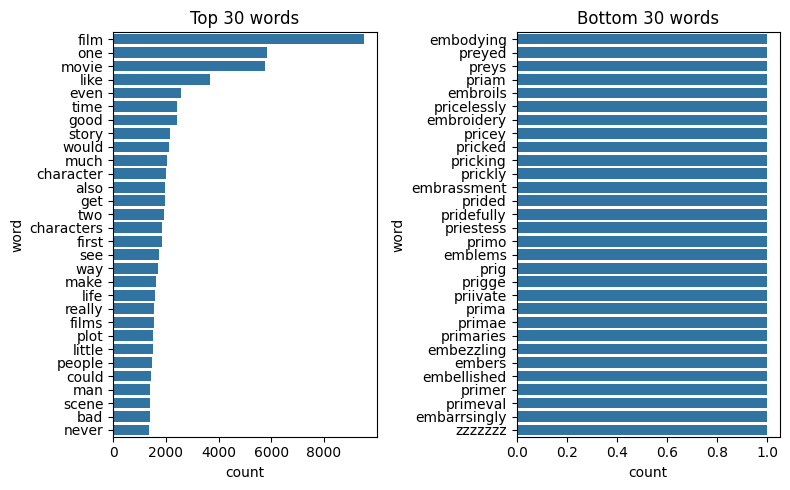

In [ ]:
vectorizer = CountVectorizer(preprocessor=preprocess, stop_words=custom_stop_words)
M = vectorizer.fit_transform(texts)
df = pd.DataFrame(data={"word":vectorizer.get_feature_names_out(), "count":M.sum(axis=0).A1}).sort_values(by="count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
sns.barplot(data=df.head(limit), y="word", x="count", ax=axes[0])
sns.barplot(data=df.tail(limit), y="word", x="count", ax=axes[1])

axes[0].set_title(f"Top {limit} words")
axes[1].set_title(f"Bottom {limit} words")

plt.tight_layout()

#### Stemming

In [ ]:
stemmer = SnowballStemmer("english", ignore_stopwords=False)
texts_clean = [preprocess(text) for text in texts]
texts_tokens = [nltk.tokenize.word_tokenize(text) for text in texts_clean]
texts_stemmed = [" ".join([stemmer.stem(word) for word in text]) for text in texts_tokens]

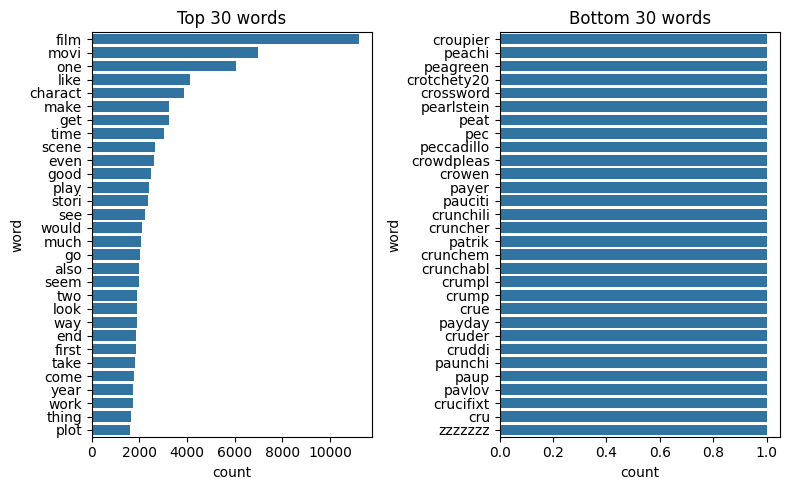

In [ ]:
# Print top/bottom 50 words after stemming
vectorizer = CountVectorizer(stop_words=None)
M = vectorizer.fit_transform(texts_stemmed)
df = pd.DataFrame(data={"word":vectorizer.get_feature_names_out(), "count":M.sum(axis=0).A1}).sort_values(by="count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
sns.barplot(data=df.head(limit), y="word", x="count", ax=axes[0])
sns.barplot(data=df.tail(limit), y="word", x="count", ax=axes[1])

axes[0].set_title(f"Top {limit} words")
axes[1].set_title(f"Bottom {limit} words")

plt.tight_layout()

#### Lemmatization

In [ ]:
# Preprocessing text
wnl = nltk.stem.WordNetLemmatizer()
pos_tags = [nltk.pos_tag(text) for text in texts_tokens]
texts_lemmas = [" ".join([wnl.lemmatize(word, penn_to_wordnet(pos)) for (word, pos) in pos_tag_text])
                for pos_tag_text in pos_tags]

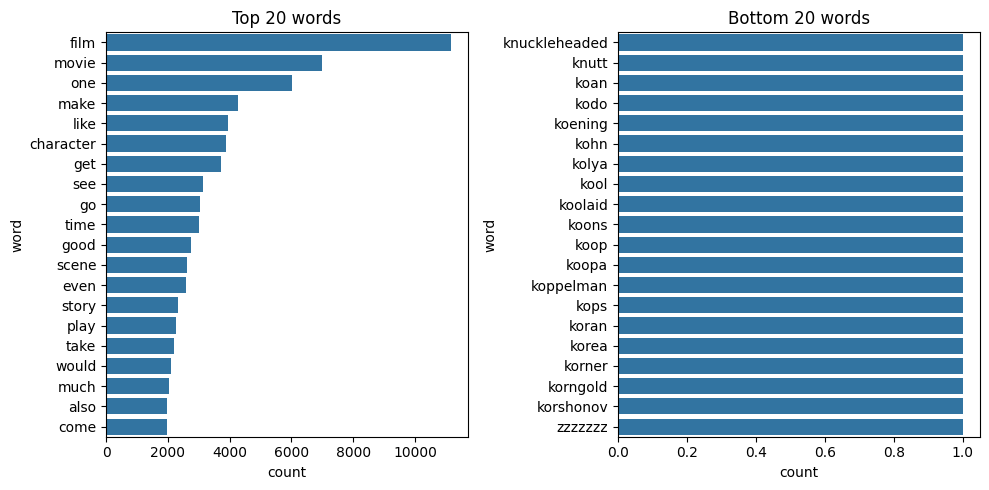

In [ ]:
# Print top/bottom 50 words after stemming
vectorizer = CountVectorizer(stop_words=None)
M = vectorizer.fit_transform(texts_lemmas)
df = pd.DataFrame(data={"word":vectorizer.get_feature_names_out(), "count":M.sum(axis=0).A1}).sort_values(by="count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
sns.barplot(data=df.head(limit), y="word", x="count", ax=axes[0])
sns.barplot(data=df.tail(limit), y="word", x="count", ax=axes[1])

axes[0].set_title(f"Top {limit} words")
axes[1].set_title(f"Bottom {limit} words")

plt.tight_layout()

#### TF-IDF

<Axes: ylabel='Count'>

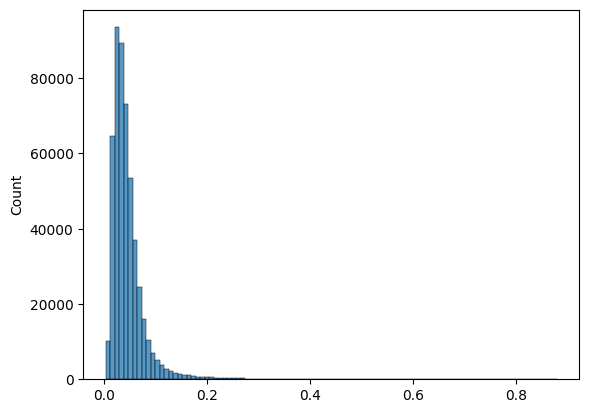

In [ ]:
vectorizer = TfidfVectorizer()
M = vectorizer.fit_transform(texts_lemmas)

values = M.toarray().flatten()
sns.histplot(values[values > 0], bins=100)

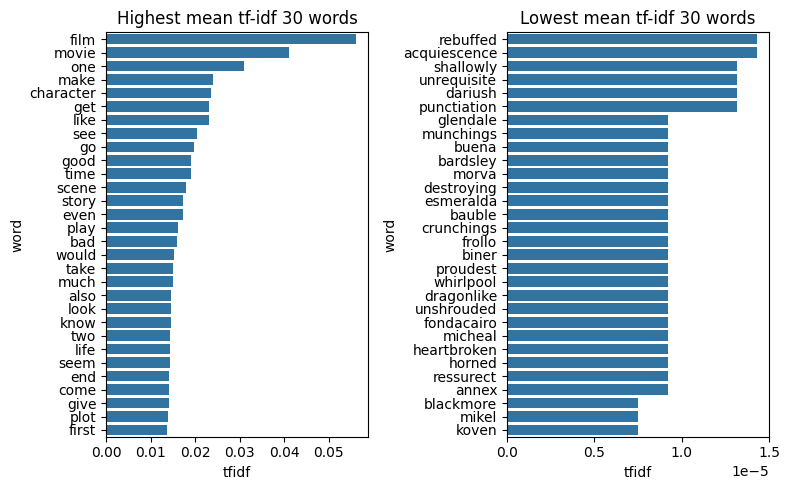

In [ ]:

df = pd.DataFrame(data={"word":vectorizer.get_feature_names_out(), "tfidf":M.mean(axis=0).A1}).sort_values("tfidf", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
sns.barplot(data=df.head(limit), y="word", x="tfidf", ax=axes[0])
sns.barplot(data=df.tail(limit), y="word", x="tfidf", ax=axes[1])

axes[0].set_title(f"Highest mean tf-idf {limit} words")
axes[1].set_title(f"Lowest mean tf-idf {limit} words")

plt.tight_layout()

### Wordclouds (positive/negative reviews)

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

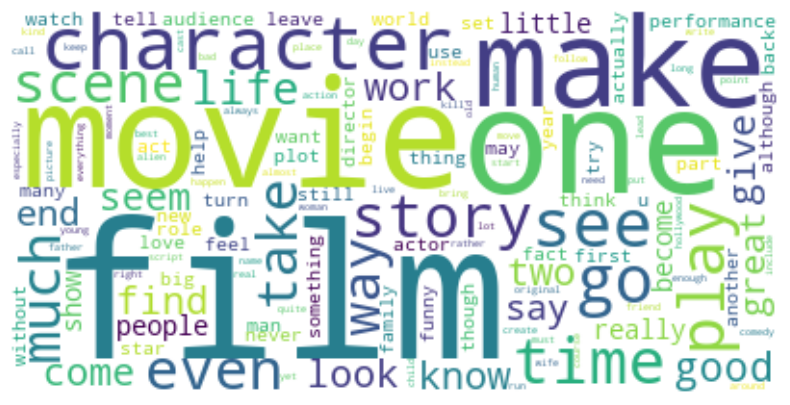

In [ ]:
# Wordcloud of positive reviews
pos_idx = np.where(classes == 1)[0]
pos_texts = ' '.join([texts_lemmas[i] for i in pos_idx])

cloud = WordCloud(background_color='white').generate(pos_texts)
plt.figure(figsize=(10, 5))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')  

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

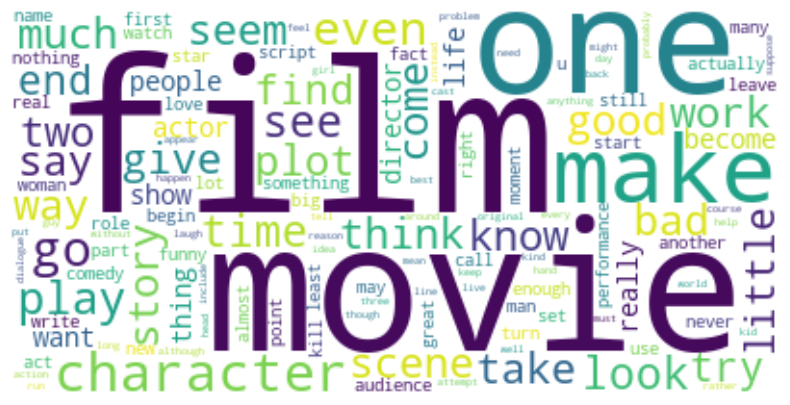

In [ ]:
# Wordcloud of negative reviews
neg_idx = np.where(classes == 0)[0]
neg_texts = ' '.join([texts_lemmas[i] for i in neg_idx])

cloud = WordCloud(background_color='white').generate(neg_texts)
plt.figure(figsize=(10, 5))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')  